In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

In [40]:
def estimate_period_fft(series, default_period=24):
    """
    FFT를 활용하여 시계열 데이터에서 가장 지배적인 주기를 동적으로 추정합니다.
    - 스펙트럼 왜곡 방지를 위해 1차적으로 선형 디트렌딩(Linear Detrending)을 수행합니다.
    """
    n = len(series)
    t = np.arange(n)
    
    # 1. FFT 전처리: 선형 추세 및 평균(DC 성분) 제거
    p = np.polyfit(t, series, 1)
    detrended = series - np.polyval(p, t)
    detrended = detrended - np.mean(detrended)
    
    # 2. FFT 수행 및 진폭 계산
    fft_vals = np.fft.rfft(detrended)
    frequencies = np.fft.rfftfreq(n)
    magnitudes = np.abs(fft_vals)
    
    # 3. 0Hz(상수항)를 제외하고 진폭이 가장 큰 인덱스 탐색
    if len(magnitudes) > 1:
        dominant_idx = np.argmax(magnitudes[1:]) + 1 
        dominant_freq = frequencies[dominant_idx]
        
        if dominant_freq > 0:
            period = int(np.round(1.0 / dominant_freq))
            # 현실적인 시계열 분석 바운더리 설정 (최소 주기 2, 최대 주기 전체 길이의 절반)
            if 2 <= period <= n // 2:
                return period
                
    return default_period

def calculate_quadrant_metrics(series):
    """
    FFT 기반으로 동적 주기를 추출한 뒤, STL 분해를 수행하여 F_T, F_S 지표를 산출합니다.
    """
    # 동적 주기 추정
    estimated_p = estimate_period_fft(series)
    
    # STL 분해 수행 (추정 주기가 유효한지 재확인)
    if len(series) < 2 * estimated_p:
        estimated_p = max(2, len(series) // 2 - 1)
        
    try:
        res = STL(series, period=estimated_p, robust=True).fit()
        T, S, R = res.trend, res.seasonal, res.resid
        
        var_R = np.var(R)
        var_TR = np.var(T + R)
        var_SR = np.var(S + R)
        
        F_T = max(0, 1 - (var_R / var_TR if var_TR > 0 else 1))
        F_S = max(0, 1 - (var_R / var_SR if var_SR > 0 else 1))
    except Exception:
        # 분해 실패 시 예외 처리 (정상성 노이즈로 간주)
        F_T, F_S = 0.0, 0.0
        
    return F_T, F_S, estimated_p

def generate_extensive_synthetic_dataset(n_samples_per_q=50, length=500):
    """
    4사분면 검증을 위해 통계적 특성이 다양한 복잡한 가상 시계열 데이터를 대량 생성합니다.
    요청하신 모든 세부 파라미터 변수들이 DataFrame 컬럼으로 명시적으로 적재됩니다.
    """
    #np.random.seed(42)
    data_records = []
    t = np.arange(length)
    
    for i in range(n_samples_per_q):
        print(f"💡 Generating sample {i+1}/{n_samples_per_q} for each regime...")
        # 무작위 고유 주기 부여 (12시간, 24시간, 48시간 단위 등 무작위화)
        rand_p1 = np.random.choice([12, 24, 36, 48])
        rand_p2 = rand_p1 * 2  # 다중 주기성 구현용
        
        # ----------------------------------------------------
        # R1: Composite Regime (강한 추세 + 강한 계절성) - 완벽 복원본
        # ----------------------------------------------------
        slope = np.random.uniform(0.1, 0.4) * np.random.choice([1, -1])
        curve = np.random.uniform(1e-5, 5e-5) * np.random.choice([1, -1])
        
        amp1 = np.random.uniform(8, 25)
        amp2 = np.random.uniform(2, 8)
        noise_std = np.random.uniform(0.5, 1.5)
        
        # 3. 어제와 한 치의 오차도 없는 완벽한 가법 합성 수식 복원
        q1_series = (slope * t + curve * (t**2)) + \
                    (amp1 * np.sin(2 * np.pi * t / rand_p1)) + \
                    (amp2 * np.cos(2 * np.pi * t / rand_p2)) + \
                    np.random.normal(0, noise_std, length)
                    
        ft, fs, p_est = calculate_quadrant_metrics(q1_series)
        data_records.append({
            'True_Regime': 'R1', 'Pattern': 'Trend+MultiSeason', 'F_T': ft, 'F_S': fs, 'True_P': rand_p1, 'Est_P': p_est,
            'rand_p1': rand_p1, 'rand_p2': rand_p2, 'length': length, 'slope': slope, 
            'curve': curve, # 단일 상숫값으로 안전하게 독립 컬럼 저장!
            'amp1': amp1, 'amp2': amp2, 'noise_std': noise_std,
            'phi': None, 'break_point': None, 'drift': None
        })
        
        # ----------------------------------------------------
        # R2: Pure Seasonal (약한 추세 + 강한 계절성)
        # ----------------------------------------------------
        amp1 = np.random.uniform(10, 30)
        amp2 = np.random.uniform(4, 12)
        noise_std = np.random.uniform(0.5, 2.0)
        
        q2_series = (amp1 * np.sin(2 * np.pi * t / rand_p1)) + \
                    (amp2 * np.sin(2 * np.pi * t / rand_p2 + np.pi/4)) + \
                    np.random.normal(0, noise_std, length)
                    
        ft, fs, p_est = calculate_quadrant_metrics(q2_series)
        data_records.append({
            'True_Regime': 'R2', 'Pattern': 'Pure_MultiSeason', 'F_T': ft, 'F_S': fs, 'True_P': rand_p1, 'Est_P': p_est,
            'rand_p1': rand_p1, 'rand_p2': rand_p2, 'length': length, 'slope': 0.0, 'curve': 0.0, 
            'amp1': amp1, 'amp2': amp2, 'noise_std': noise_std,
            'phi': None, 'break_point': None, 'drift': None
        })
        
        # ----------------------------------------------------
        # R3: Stationary / Noise (약한 추세 + 약한 계절성)
        # ----------------------------------------------------
        noise_type = np.random.choice(['WN', 'AR'])
        phi_val = None
        
        if noise_type == 'WN':
            noise_std_wn = np.random.uniform(5, 15)
            q3_series = np.random.normal(0, noise_std_wn, length)
            current_noise_std = noise_std_wn
        else:
            phi_val = np.random.uniform(0.4, 0.7)
            q3_series = np.zeros(length)
            innovations_std = 5.0
            innovations = np.random.normal(0, innovations_std, length)
            q3_series[0] = innovations[0]
            for idx in range(1, length):
                q3_series[idx] = phi_val * q3_series[idx-1] + innovations[idx]
            current_noise_std = innovations_std
                
        ft, fs, p_est = calculate_quadrant_metrics(q3_series)
        data_records.append({
            'True_Regime': 'R3', 'Pattern': f'Stationary_{noise_type}', 'F_T': ft, 'F_S': fs, 'True_P': 'None', 'Est_P': p_est,
            'rand_p1': None, 'rand_p2': None, 'length': length, 'slope': 0.0, 'curve': 0.0, 
            'amp1': 0.0, 'amp2': 0.0, 'noise_std': current_noise_std,
            'phi': phi_val, 'break_point': None, 'drift': None
        })

        # ----------------------------------------------------
        # R4: Pure Trending (강한 추세 + 약한 계절성)
        # ----------------------------------------------------
        trend_type = np.random.choice(['Break', 'RandomWalk', 'Exponential'])
        noise_std = np.random.uniform(0.5, 1.5)
        
        bp_val = None
        drift_val = None
        
        if trend_type == 'Break':
            bp_val = length // 2
            q4_series = np.random.normal(0, noise_std, length)
            q4_series[bp_val:] += np.random.uniform(50, 150)
        elif trend_type == 'RandomWalk':
            drift_val = np.random.uniform(0.1, 0.5) * np.random.choice([1, -1])
            q4_series = np.cumsum(np.random.normal(drift_val, 2, length))
        else:
            # Exponential Growth
            q4_series = np.exp(np.linspace(0, np.random.uniform(3, 5), length)) + np.random.normal(0, noise_std, length)
            
        ft, fs, p_est = calculate_quadrant_metrics(q4_series)
        data_records.append({
            'True_Regime': 'R4', 'Pattern': f'PureTrend_{trend_type}', 'F_T': ft, 'F_S': fs, 'True_P': 'None', 'Est_P': p_est,
            'rand_p1': None, 'rand_p2': None, 'length': length, 'slope': None, 'curve': None, 
            'amp1': 0.0, 'amp2': 0.0, 'noise_std': noise_std,
            'phi': None, 'break_point': bp_val, 'drift': drift_val
        })
        
    return pd.DataFrame(data_records)

# 코드 정상 작동 테스트
#df_final = generate_extensive_synthetic_dataset(n_samples_per_q=5, length=500)

In [ ]:
# ==========================================
# 1. 시뮬레이션 데이터 생성 (각 사분면별 10000개, 총 40000개 시퀀스)
# ==========================================
print("💡 다양한 패턴의 합성 시계열 데이터를 대량 생성 및 오라클 라우팅 분석 중...")
df_exp_results = generate_extensive_synthetic_dataset(n_samples_per_q=10000, length=500)

💡 다양한 패턴의 합성 시계열 데이터를 대량 생성 및 오라클 라우팅 분석 중...
💡 Generating sample 1/10 for each regime...
💡 Generating sample 2/10 for each regime...
💡 Generating sample 3/10 for each regime...
💡 Generating sample 4/10 for each regime...
💡 Generating sample 5/10 for each regime...
💡 Generating sample 6/10 for each regime...
💡 Generating sample 7/10 for each regime...
💡 Generating sample 8/10 for each regime...
💡 Generating sample 9/10 for each regime...
💡 Generating sample 10/10 for each regime...


In [43]:
df_exp_results

,True_Regime,Pattern,F_T,F_S,True_P,Est_P,rand_p1,rand_p2,length,slope,curve,amp1,amp2,noise_std,phi,break_point,drift
0,R1,Trend+MultiSeason,0.997227,0.965795,36,36,36.0,72.0,500,-0.388316,0.000042,21.234318,7.108938,1.118034,NaN,NaN,NaN
1,R2,Pure_MultiSeason,0.730771,0.887995,36,36,36.0,72.0,500,0.000000,0.000000,13.053901,8.485322,0.888732,NaN,NaN,NaN
2,R3,Stationary_WN,0.208658,0.125973,None,2,NaN,NaN,500,0.000000,0.000000,0.000000,0.000000,13.106767,NaN,NaN,NaN
3,R4,PureTrend_RandomWalk,0.977779,0.116699,None,24,NaN,NaN,500,NaN,NaN,0.000000,0.000000,0.991079,NaN,NaN,0.111737
4,R1,Trend+MultiSeason,0.994013,0.980995,12,12,12.0,24.0,500,0.161796,-0.000024,16.951604,2.339203,1.343131,NaN,NaN,NaN
5,R2,Pure_MultiSeason,0.759825,0.897454,12,12,12.0,24.0,500,0.000000,0.000000,17.051248,11.557027,0.798374,NaN,NaN,NaN
6,R3,Stationary_AR,0.080972,0.217579,None,28,NaN,NaN,500,0.000000,0.000000,0.000000,0.000000,5.000000,0.444771,NaN,NaN
7,R4,PureTrend_Break,0.999967,0.999869,None,250,NaN,NaN,500,NaN,NaN,0.000000,0.000000,0.964766,NaN,250.0,NaN
8,R1,Trend+MultiSeason,0.991677,0.963229,48,100,48.0,96.0,500,0.141319,-0.000046,8.554675,7.099792,1.441965,NaN,NaN,NaN
9,R2,Pure_MultiSeason,0.488033,0.988040,48,50,48.0,96.0,500,0.000000,0.000000,29.658257,4.068476,1.131781,NaN,NaN,NaN


In [20]:
df_exp_results.to_csv('../../results/temp/synthetic_quadrant_dataset.csv', index=False)

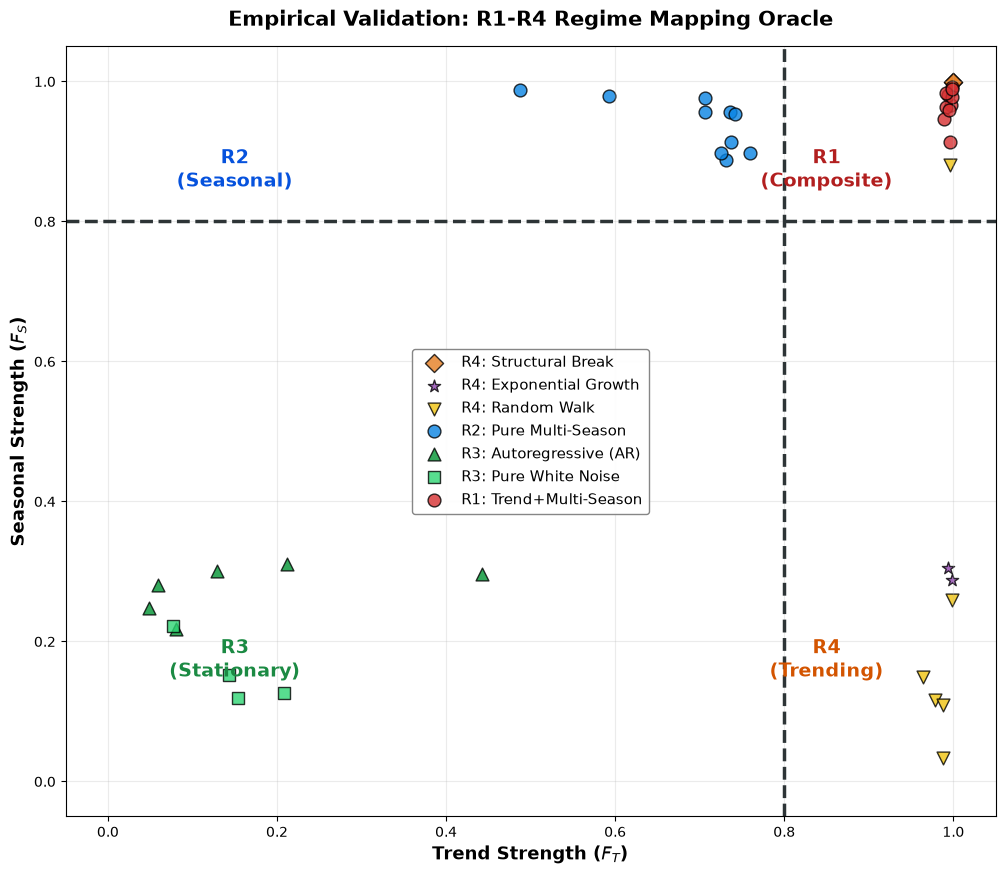


     [오라클 검증 통계 리포트 (임계치: 0.64)]
▶ R1: Composite Regime
  - 생성 패턴 예시: <ArrowStringArray>['Trend+MultiSeason']Length: 1, dtype: str
  - 평균 지표값  : Mean F_T = 0.995 | Mean F_S = 0.967
  - FFT 주기 추정 정확도: 80.0%
  - 사분면 매핑 성공률 : [ 10 / 10 ] (100.0%)
------------------------------------------------------------
▶ R2: Seasonal Regime
  - 생성 패턴 예시: <ArrowStringArray>['Pure_MultiSeason']Length: 1, dtype: str
  - 평균 지표값  : Mean F_T = 0.692 | Mean F_S = 0.941
  - FFT 주기 추정 정확도: 80.0%
  - 사분면 매핑 성공률 : [ 10 / 10 ] (100.0%)
------------------------------------------------------------
▶ R3: Stationary Regime
  - 생성 패턴 예시: <ArrowStringArray>['Stationary_WN', 'Stationary_AR']Length: 2, dtype: str
  - 평균 지표값  : Mean F_T = 0.155 | Mean F_S = 0.227
  - 사분면 매핑 성공률 : [ 10 / 10 ] (100.0%)
------------------------------------------------------------
▶ R4: Trending Regime
  - 생성 패턴 예시: <ArrowStringArray>['PureTrend_RandomWalk', 'PureTrend_Break', 'PureTrend_Exponential']Length: 3, dtype: str
  - 평균 지표값  : Mean 

In [44]:
# ==========================================
# 2. 결과 시각화 (세부 패턴별 색상 및 마커 분리 플롯팅)
# ==========================================
F_T_thr = 0.80
F_S_thr = 0.80

plt.figure(figsize=(12, 10))

# 패턴별 구성 설정
pattern_configs = {
    'Trend+MultiSeason':       {'color': '#d63031', 'marker': 'o', 'label': 'R1: Trend+Multi-Season'},
    'Pure_MultiSeason':        {'color': '#0984e3', 'marker': 'o', 'label': 'R2: Pure Multi-Season'},
    'Stationary_WN':           {'color': '#2ed573', 'marker': 's', 'label': 'R3: Pure White Noise'},
    'Stationary_AR':           {'color': '#009432', 'marker': '^', 'label': 'R3: Autoregressive (AR)'},
    'PureTrend_Break':         {'color': '#e67e22', 'marker': 'D', 'label': 'R4: Structural Break'},
    'PureTrend_RandomWalk':    {'color': '#f1c40f', 'marker': 'v', 'label': 'R4: Random Walk'},
    'PureTrend_Exponential':   {'color': '#8e44ad', 'marker': '*', 'label': 'R4: Exponential Growth'}
}

# 시각화 수행
for pattern_label, group in df_exp_results.groupby('Pattern'):
    config = pattern_configs.get(pattern_label, {'color': '#7f8c8d', 'marker': 'x', 'label': pattern_label})
    plt.scatter(group['F_T'], group['F_S'], 
                label=config['label'], color=config['color'], marker=config['marker'],
                alpha=0.8, edgecolors='k', s=85)

# 하드 임계치 선
plt.axvline(x=F_T_thr, color='#2d3436', linestyle='--', linewidth=2.5)
plt.axhline(y=F_S_thr, color='#2d3436', linestyle='--', linewidth=2.5)

# 사분면 영역 명칭 표기
plt.text(0.85, 0.85, 'R1\n(Composite)', fontsize=14, fontweight='bold', ha='center', color='#b21f1f')
plt.text(0.15, 0.85, 'R2\n(Seasonal)', fontsize=14, fontweight='bold', ha='center', color='#0652dd')
plt.text(0.15, 0.15, 'R3\n(Stationary)', fontsize=14, fontweight='bold', ha='center', color='#1b8a43')
plt.text(0.85, 0.15, 'R4\n(Trending)', fontsize=14, fontweight='bold', ha='center', color='#d35400')

# 축 설정 및 레이아웃 조정
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Trend Strength ($F_T$)', fontsize=13, fontweight='bold')
plt.ylabel('Seasonal Strength ($F_S$)', fontsize=13, fontweight='bold')
plt.title('Empirical Validation: R1-R4 Regime Mapping Oracle', fontsize=15, fontweight='bold', pad=15)

# 요청하신 범례 중앙 배치
plt.legend(loc='center', fontsize=11, framealpha=0.95, facecolor='white', edgecolor='gray')
plt.grid(True, alpha=0.25)
plt.show()

# ==========================================
# 3. 오라클 분류 정확도 결산 리포트 출력
# ==========================================
print("\n" + "="*60)
print("     [오라클 검증 통계 리포트 (임계치: 0.64)]")
print("="*60)

regime_names = {'R1': 'Composite Regime', 'R2': 'Seasonal Regime', 'R3': 'Stationary Regime', 'R4': 'Trending Regime'}

total_success = 0
# 데이터셋 내의 고유 레짐 라벨을 기준으로 루프 실행
for r_label in ['R1', 'R2', 'R3', 'R4']:
    sub_df = df_exp_results[df_exp_results['True_Regime'] == r_label]
    
    # 사분면 조건문 (R1~R4 로직 반영)
    if r_label == 'R1':
        success_condition = (sub_df['F_T'] >= F_T_thr) & (sub_df['F_S'] >= F_S_thr)
    elif r_label == 'R2':
        success_condition = (sub_df['F_T'] < F_T_thr) & (sub_df['F_S'] >= F_S_thr)
    elif r_label == 'R3':
        success_condition = (sub_df['F_T'] < F_T_thr) & (sub_df['F_S'] < F_S_thr)
    elif r_label == 'R4':
        success_condition = (sub_df['F_T'] >= F_T_thr) & (sub_df['F_S'] < F_S_thr)
        
    success_count = len(sub_df[success_condition])
    total_success += success_count
    accuracy = (success_count / len(sub_df)) * 100
    
    unique_patterns = list(sub_df['Pattern'].unique())
    print(f"▶ {r_label}: {regime_names[r_label]}")
    print(f"  - 생성 패턴 예시: <ArrowStringArray>{unique_patterns}Length: {len(unique_patterns)}, dtype: str")
    print(f"  - 평균 지표값  : Mean F_T = {sub_df['F_T'].mean():.3f} | Mean F_S = {sub_df['F_S'].mean():.3f}")
    
    # 주기 매칭 검증 (R1, R2에 대해서만 추출 성과 체크)
    if r_label in ['R1', 'R2']:
        same_p_count = len(sub_df[sub_df['True_P'] == sub_df['Est_P']])
        p_match_rate = (same_p_count / len(sub_df)) * 100
        print(f"  - FFT 주기 추정 정확도: {p_match_rate:.1f}%")
        
    print(f"  - 사분면 매핑 성공률 : [ {success_count} / {len(sub_df)} ] ({accuracy:.1f}%)")
    print("-" * 60)

print(f"■ 전체 통합 오라클 라우팅 정확도: {(total_success / len(df_exp_results))*100:.2f}%")
print("="*60)

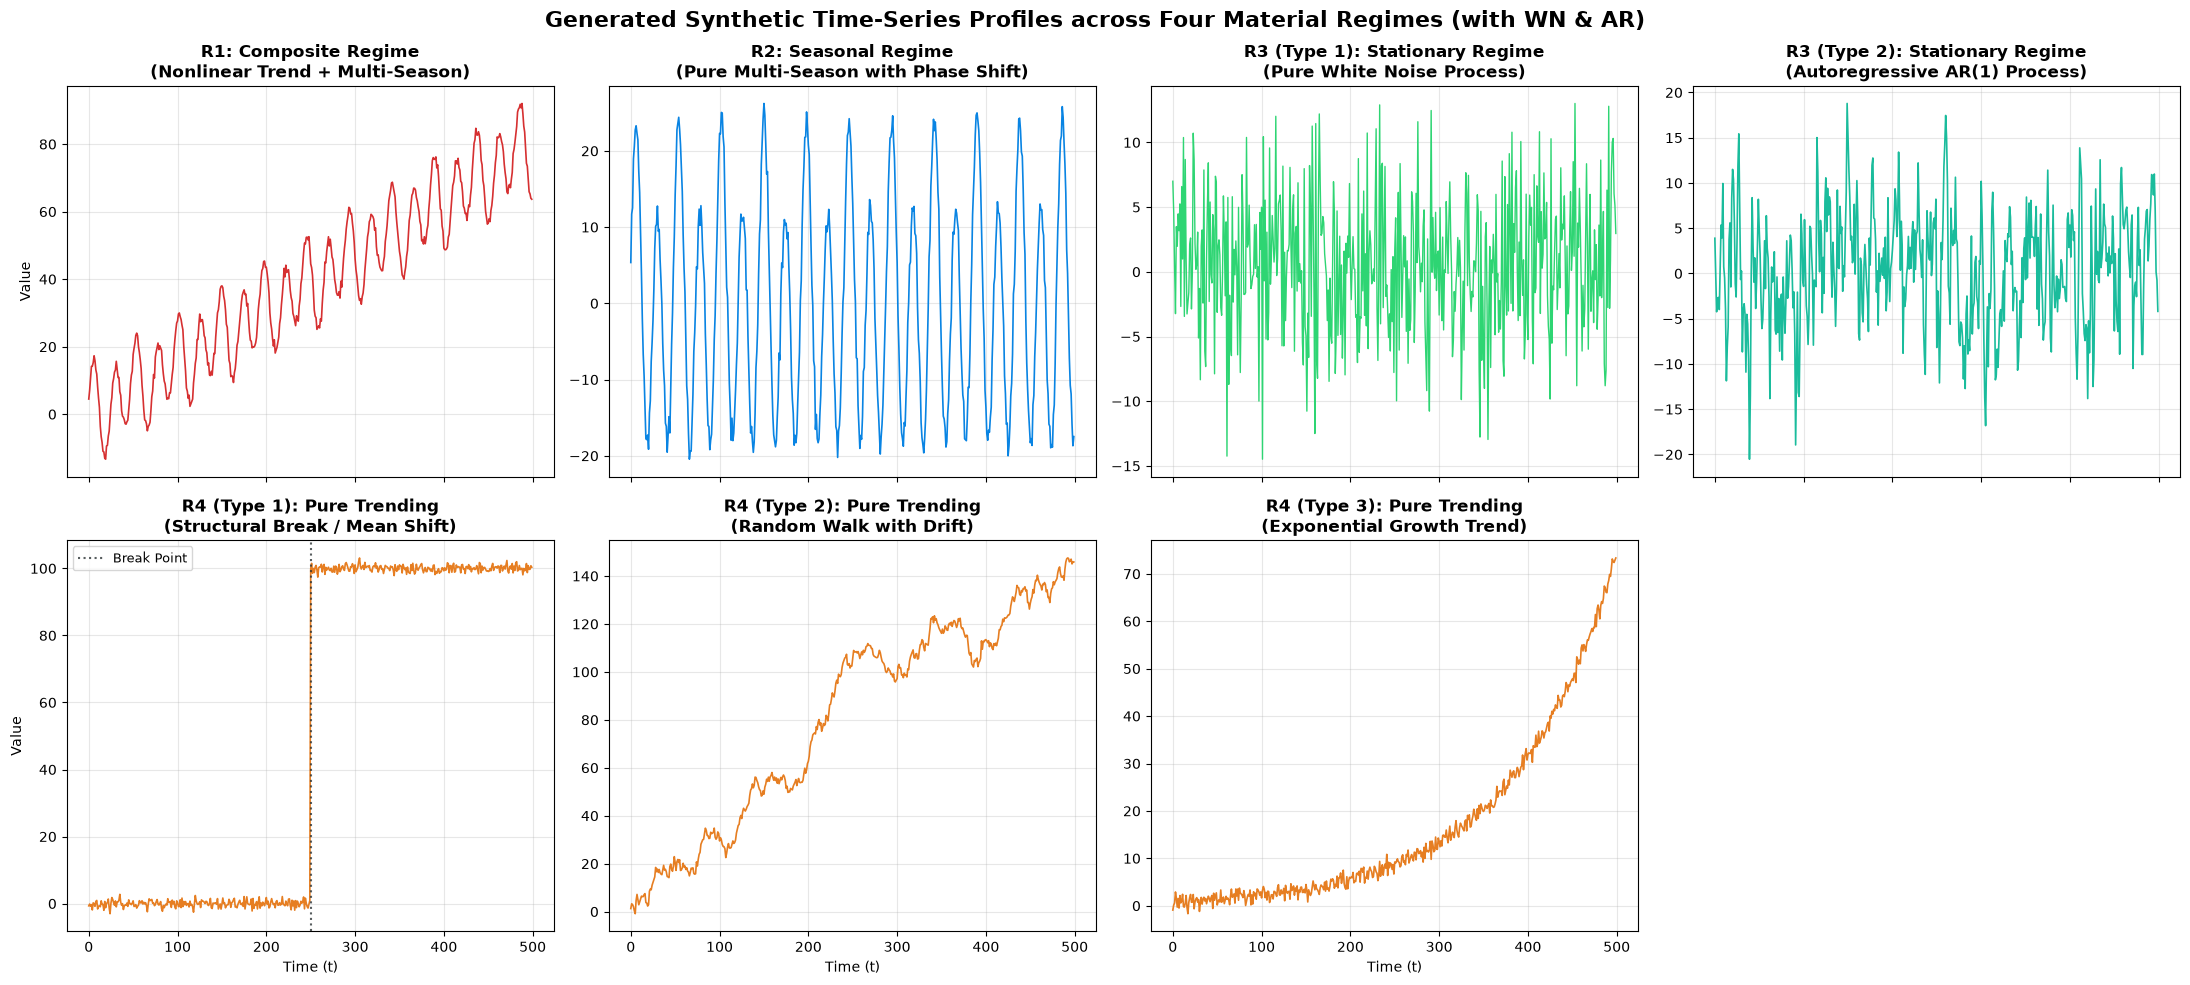

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 0. 글로벌 가상 데이터 공통 설정
# ----------------------------------------------------
length = 500
t = np.arange(length)
np.random.seed(42)  # 실험 재현성을 위한 시드 고정

# 서브플롯 Grid 구성 (2행 4열, 총 8개 패널로 확장)
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex=True)
axes = axes.flatten()

# ----------------------------------------------------
# 1. 🔴 R1 (Composite Regime): 강한 추세 + 강한 계절성
# ----------------------------------------------------
slope = 0.15
curve = 2e-5
amp1, amp2 = 12.0, 4.0
p1, p2 = 24, 48
noise_std_r1 = 1.0

y_R1 = (slope * t + curve * (t**2)) + \
       (amp1 * np.sin(2 * np.pi * t / p1)) + \
       (amp2 * np.cos(2 * np.pi * t / p2)) + \
       np.random.normal(0, noise_std_r1, length)

axes[0].plot(t, y_R1, color='#d63031', linewidth=1.2)
axes[0].set_title("R1: Composite Regime\n(Nonlinear Trend + Multi-Season)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Value", fontsize=10)
axes[0].grid(True, alpha=0.3)

# ----------------------------------------------------
# 2. 🔵 R2 (Seasonal Regime): 약한 추세 + 강한 계절성
# ----------------------------------------------------
amp1_r2, amp2_r2 = 18.0, 6.0
p1_r2, p2_r2 = 24, 48
noise_std_r2 = 1.2

y_R2 = (amp1_r2 * np.sin(2 * np.pi * t / p1_r2)) + \
       (amp2_r2 * np.sin(2 * np.pi * t / p2_r2 + np.pi/4)) + \
       np.random.normal(0, noise_std_r2, length)

axes[1].plot(t, y_R2, color='#0984e3', linewidth=1.2)
axes[1].set_title("R2: Seasonal Regime\n(Pure Multi-Season with Phase Shift)", fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# ----------------------------------------------------
# 3. 🟢 R3 (Type 1): 순수 화이트 노이즈 (White Noise) ★추가된 부분
# ----------------------------------------------------
# AR(1)과 동일한 수준의 충격 스케일을 직관적으로 비교하기 위해 표준편차 설정
y_R3_wn = np.random.normal(0, 5.0, length)

axes[2].plot(t, y_R3_wn, color='#2ed573', linewidth=1.0)
axes[2].set_title("R3 (Type 1): Stationary Regime\n(Pure White Noise Process)", fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# ----------------------------------------------------
# 4. 🟢 R3 (Type 2): 1차 자기회귀 프로세스 (AR(1) Process)
# ----------------------------------------------------
phi = 0.65
y_R3_ar = np.zeros(length)
innovations = np.random.normal(0, 5.0, length)
y_R3_ar[0] = innovations[0]
for idx in range(1, length):
    y_R3_ar[idx] = phi * y_R3_ar[idx-1] + innovations[idx]

axes[3].plot(t, y_R3_ar, color='#1abc9c', linewidth=1.2)
axes[3].set_title("R3 (Type 2): Stationary Regime\n(Autoregressive AR(1) Process)", fontsize=12, fontweight='bold')
axes[3].grid(True, alpha=0.3)

# ----------------------------------------------------
# 5. 🟠 R4 - 변형 1: 구조적 단절 (Structural Break)
# ----------------------------------------------------
break_point = length // 2
y_R4_break = np.random.normal(0, 1.0, length)
y_R4_break[break_point:] += 100.0  # 평균 수직 도약 (Mean Shift)

axes[4].plot(t, y_R4_break, color='#e67e22', linewidth=1.2)
axes[4].axvline(x=break_point, color='#2d3436', linestyle=':', alpha=0.8, label='Break Point')
axes[4].set_title("R4 (Type 1): Pure Trending\n(Structural Break / Mean Shift)", fontsize=12, fontweight='bold')
axes[4].set_xlabel("Time (t)", fontsize=10)
axes[4].set_ylabel("Value", fontsize=10)
axes[4].legend(loc='upper left', fontsize=9)
axes[4].grid(True, alpha=0.3)

# ----------------------------------------------------
# 6. 🟠 R4 - 변형 2: 드리프트 랜덤 워크 (Random Walk with Drift)
# ----------------------------------------------------
drift = 0.25
y_R4_rw = np.cumsum(np.random.normal(drift, 1.8, length))  # 누적 충격 확률과정

axes[5].plot(t, y_R4_rw, color='#e67e22', linewidth=1.2)
axes[5].set_title("R4 (Type 2): Pure Trending\n(Random Walk with Drift)", fontsize=12, fontweight='bold')
axes[5].set_xlabel("Time (t)", fontsize=10)
axes[5].grid(True, alpha=0.3)

# ----------------------------------------------------
# 7. 🟠 R4 - 변형 3: 지수 성장 트렌드 (Exponential Growth Trend)
# ----------------------------------------------------
y_R4_exp = np.exp(np.linspace(0, 4.3, length)) + np.random.normal(0, 1.0, length)

axes[6].plot(t, y_R4_exp, color='#e67e22', linewidth=1.2)
axes[6].set_title("R4 (Type 3): Pure Trending\n(Exponential Growth Trend)", fontsize=12, fontweight='bold')
axes[6].set_xlabel("Time (t)", fontsize=10)
axes[6].grid(True, alpha=0.3)

# ----------------------------------------------------
# 8. 📊 마지막 빈 슬롯 레이아웃 여백 처리
# ----------------------------------------------------
axes[7].axis('off')  # 시각적 왜곡이 없도록 빈 패널 숨기기

# 전체 레이아웃 조율
plt.suptitle("Generated Synthetic Time-Series Profiles across Four Material Regimes (with WN & AR)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

💡 다양한 패턴의 합성 시계열 데이터를 대량 생성 및 오라클 라우팅 분석 중...


c:\Users\wayne\Desktop\PythonProject\TSFM_Ops\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\wayne\Desktop\PythonProject\TSFM_Ops\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


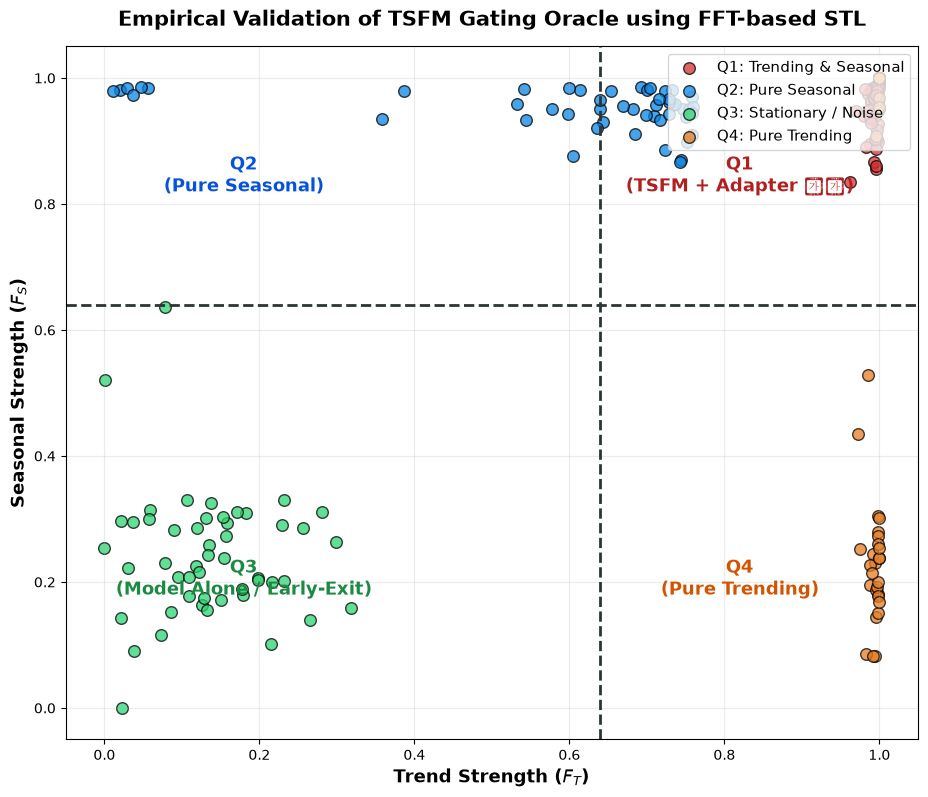


     [오라클 검증 통계 리포트 (임계치: 0.64)]
▶ Q1: Trending & Seasonal
  - 생성 패턴 예시: <StringArray>
['Trend+MultiSeason']
Length: 1, dtype: str
  - 평균 지표값  : Mean F_T = 0.993 | Mean F_S = 0.948
  - FFT 주기 추정 정확도: 64.0%
  - 사분면 매핑 성공률 : [ 50 / 50 ] (100.0%)
------------------------------------------------------------
▶ Q2: Pure Seasonal
  - 생성 패턴 예시: <StringArray>
['Pure_MultiSeason']
Length: 1, dtype: str
  - 평균 지표값  : Mean F_T = 0.596 | Mean F_S = 0.951
  - FFT 주기 추정 정확도: 64.0%
  - 사분면 매핑 성공률 : [ 19 / 50 ] (38.0%)
------------------------------------------------------------
▶ Q3: Stationary / Noise
  - 생성 패턴 예시: <StringArray>
['Stationary_AR', 'Stationary_WN']
Length: 2, dtype: str
  - 평균 지표값  : Mean F_T = 0.136 | Mean F_S = 0.242
  - 사분면 매핑 성공률 : [ 50 / 50 ] (100.0%)
------------------------------------------------------------
▶ Q4: Pure Trending
  - 생성 패턴 예시: <StringArray>
['PureTrend_Break', 'PureTrend_RandomWalk', 'PureTrend_Exponential']
Length: 3, dtype: str
  - 평균 지표값  : Mean F_T = 0.996 |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

def estimate_period_fft(series, default_period=24):
    """
    FFT를 활용하여 시계열 데이터에서 가장 지배적인 주기를 동적으로 추정합니다.
    - 스펙트럼 왜곡 방지를 위해 1차적으로 선형 디트렌딩(Linear Detrending)을 수행합니다.
    """
    n = len(series)
    t = np.arange(n)
    
    # 1. FFT 전처리: 선형 추세 및 평균(DC 성분) 제거
    p = np.polyfit(t, series, 1)
    detrended = series - np.polyval(p, t)
    detrended = detrended - np.mean(detrended)
    
    # 2. FFT 수행 및 진폭 계산
    fft_vals = np.fft.rfft(detrended)
    frequencies = np.fft.rfftfreq(n)
    magnitudes = np.abs(fft_vals)
    
    # 3. 0Hz(상수항)를 제외하고 진폭이 가장 큰 인덱스 탐색
    if len(magnitudes) > 1:
        dominant_idx = np.argmax(magnitudes[1:]) + 1 
        dominant_freq = frequencies[dominant_idx]
        
        if dominant_freq > 0:
            period = int(np.round(1.0 / dominant_freq))
            # 현실적인 시계열 분석 바운더리 설정 (최소 주기 2, 최대 주기 전체 길이의 절반)
            if 2 <= period <= n // 2:
                return period
                
    return default_period

def calculate_quadrant_metrics(series):
    """
    FFT 기반으로 동적 주기를 추출한 뒤, STL 분해를 수행하여 F_T, F_S 지표를 산출합니다.
    """
    # 동적 주기 추정
    estimated_p = estimate_period_fft(series)
    
    # STL 분해 수행 (추정 주기가 유효한지 재확인)
    if len(series) < 2 * estimated_p:
        estimated_p = max(2, len(series) // 2 - 1)
        
    try:
        res = STL(series, period=estimated_p, robust=True).fit()
        T, S, R = res.trend, res.seasonal, res.resid
        
        var_R = np.var(R)
        var_TR = np.var(T + R)
        var_SR = np.var(S + R)
        
        F_T = max(0, 1 - (var_R / var_TR if var_TR > 0 else 1))
        F_S = max(0, 1 - (var_R / var_SR if var_SR > 0 else 1))
    except Exception:
        # 분해 실패 시 예외 처리 (정상성 노이즈로 간주)
        F_T, F_S = 0.0, 0.0
        
    return F_T, F_S, estimated_p

def generate_extensive_synthetic_dataset(n_samples_per_q=50, length=500):
    """
    4사분면 검증을 위해 통계적 특성이 다양한 복잡한 가상 시계열 데이터를 대량 생성합니다.
    """
    np.random.seed(42)
    data_records = []
    t = np.arange(length)
    
    for i in range(n_samples_per_q):
        # 무작위 고유 주기 부여 (12시간, 24시간, 48시간 단위 등 무작위화)
        rand_p1 = np.random.choice([12, 24, 36, 48])
        rand_p2 = rand_p1 * 2  # 다중 주기성 구현용
        
        # ----------------------------------------------------
        # Q1: Trending & Seasonal (강한 추세 + 강한 계절성)
        # ----------------------------------------------------
        # 선형+이차 추세와 복합 사인파 결합, 미미한 노이즈
        slope = np.random.uniform(0.1, 0.4) * np.random.choice([1, -1])
        curve = np.random.uniform(1e-5, 5e-5) * (t**2) * np.random.choice([1, -1])
        amp1 = np.random.uniform(8, 25)
        amp2 = np.random.uniform(2, 8)
        noise_std = np.random.uniform(0.5, 1.5)
        
        q1_series = (slope * t + `curve`) + \
                    (amp1 * np.sin(2 * np.pi * t / rand_p1)) + \
                    (amp2 * np.cos(2 * np.pi * t / rand_p2)) + \
                    np.random.normal(0, noise_std, length)
                    
        ft, fs, p_est = calculate_quadrant_metrics(q1_series)
        data_records.append({'True_Quadrant': 'Q1', 'Pattern': 'Trend+MultiSeason', 'F_T': ft, 'F_S': fs, 'True_P': rand_p1, 'Est_P': p_est})
        
        # ----------------------------------------------------
        # Q2: Pure Seasonal (약한 추세 + 강한 계절성)
        # ----------------------------------------------------
        # 평균 0 바운더리 내 감쇄 진동 주기성 또는 복합 주기성, 미미한 노이즈
        amp1 = np.random.uniform(10, 30)
        amp2 = np.random.uniform(4, 12)
        noise_std = np.random.uniform(0.5, 2.0)
        
        # 주기가 명확한 복합 신호
        q2_series = (amp1 * np.sin(2 * np.pi * t / rand_p1)) + \
                    (amp2 * np.sin(2 * np.pi * t / rand_p2 + np.pi/4)) + \
                    np.random.normal(0, noise_std, length)
                    
        ft, fs, p_est = calculate_quadrant_metrics(q2_series)
        data_records.append({'True_Quadrant': 'Q2', 'Pattern': 'Pure_MultiSeason', 'F_T': ft, 'F_S': fs, 'True_P': rand_p1, 'Est_P': p_est})
        
        # ----------------------------------------------------
        # Q3: Stationary / Noise (약한 추세 + 약한 계절성)
        # ----------------------------------------------------
        # 화이트 노이즈, 강한 AR(1)/MA(1) 프로세스 (계절성과 무관한 노이즈성 상관관계)
        noise_type = np.random.choice(['WN', 'AR'])
        if noise_type == 'WN':
            q3_series = np.random.normal(0, np.random.uniform(5, 15), length)
        else:
            # 약한 자기회귀 시계열 생성
            phi = np.random.uniform(0.4, 0.7)
            q3_series = np.zeros(length)
            innovations = np.random.normal(0, 5, length)
            q3_series[0] = innovations[0]
            for idx in range(1, length):
                q3_series[idx] = phi * q3_series[idx-1] + innovations[idx]
                
        ft, fs, p_est = calculate_quadrant_metrics(q3_series)
        data_records.append({'True_Quadrant': 'Q3', 'Pattern': f'Stationary_{noise_type}', 'F_T': ft, 'F_S': fs, 'True_P': 'None', 'Est_P': p_est})
        
        # ----------------------------------------------------
        # Q4: Pure Trending (강한 추세 + 약한 계절성)
        # ----------------------------------------------------
        # 구조적 단절(Structural Break)이 있는 급격한 추세, 랜덤 워크(Drift 포함), 지수 성장
        trend_type = np.random.choice(['Break', 'RandomWalk', 'Exponential'])
        noise_std = np.random.uniform(0.5, 1.5)
        
        if trend_type == 'Break':
            # 특정 시점에 평균이 급변하는 구조적 단절 패턴
            break_point = length // 2
            q4_series = np.random.normal(0, noise_std, length)
            q4_series[break_point:] += np.random.uniform(50, 150)
        elif trend_type == 'RandomWalk':
            # 누적 합 기반의 랜덤 워크 (Drift 포함)
            drift = np.random.uniform(0.1, 0.5) * np.random.choice([1, -1])
            q4_series = np.cumsum(np.random.normal(drift, 2, length))
        else:
            # 지수 형태로 우상향하는 추세
            q4_series = np.exp(np.linspace(0, np.random.uniform(3, 5), length)) + np.random.normal(0, noise_std, length)
            
        ft, fs, p_est = calculate_quadrant_metrics(q4_series)
        data_records.append({'True_Quadrant': 'Q4', 'Pattern': f'PureTrend_{trend_type}', 'F_T': ft, 'F_S': fs, 'True_P': 'None', 'Est_P': p_est})
        
    return pd.DataFrame(data_records)

# ==========================================
# 1. 시뮬레이션 데이터 생성 (각 사분면별 50개, 총 200개 시퀀스)
# ==========================================
print("💡 다양한 패턴의 합성 시계열 데이터를 대량 생성 및 오라클 라우팅 분석 중...")
df_exp_results = generate_extensive_synthetic_dataset(n_samples_per_q=50, length=500)

# ==========================================
# 2. 결과 시각화 (사분면 맵 플롯팅)
# ==========================================
plt.figure(figsize=(11, 9))
quadrant_colors = {'Q1': '#d63031', 'Q2': '#0984e3', 'Q3': '#2ed573', 'Q4': '#e67e22'}
quadrant_names = {
    'Q1': 'Q1: Trending & Seasonal',
    'Q2': 'Q2: Pure Seasonal',
    'Q3': 'Q3: Stationary / Noise',
    'Q4': 'Q4: Pure Trending'
}

for q_label, group in df_exp_results.groupby('True_Quadrant'):
    plt.scatter(group['F_T'], group['F_S'], 
                label=quadrant_names[q_label], 
                color=quadrant_colors[q_label], 
                alpha=0.75, edgecolors='k', s=70)

# 임계치 가이드라인 (tau = 0.64)
plt.axvline(x=0.64, color='#2d3436', linestyle='--', linewidth=2)
plt.axhline(y=0.64, color='#2d3436', linestyle='--', linewidth=2)

# 각 사분면 영역 텍스트 표기
plt.text(0.82, 0.82, 'Q1\n(TSFM + Adapter 필수)', fontsize=13, fontweight='bold', ha='center', color='#b21f1f')
plt.text(0.18, 0.82, 'Q2\n(Pure Seasonal)', fontsize=13, fontweight='bold', ha='center', color='#0652dd')
plt.text(0.18, 0.18, 'Q3\n(Model Alone / Early-Exit)', fontsize=13, fontweight='bold', ha='center', color='#1b8a43')
plt.text(0.82, 0.18, 'Q4\n(Pure Trending)', fontsize=13, fontweight='bold', ha='center', color='#d35400')

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Trend Strength ($F_T$)', fontsize=13, fontweight='bold')
plt.ylabel('Seasonal Strength ($F_S$)', fontsize=13, fontweight='bold')
plt.title('Empirical Validation of TSFM Gating Oracle using FFT-based STL', fontsize=15, fontweight='bold', pad=15)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.25)
plt.show()

# ==========================================
# 3. 오라클 분류 정확도 결산 리포트 출력
# ==========================================
print("\n" + "="*60)
print("     [오라클 검증 통계 리포트 (임계치: 0.64)]")
print("="*60)

total_success = 0
for q_label in ['Q1', 'Q2', 'Q3', 'Q4']:
    sub_df = df_exp_results[df_exp_results['True_Quadrant'] == q_label]
    
    # 0.64 문턱값 기준 분류 성공 여부 판단 수식
    if q_label == 'Q1':
        success_condition = (sub_df['F_T'] >= 0.64) & (sub_df['F_S'] >= 0.64)
    elif q_label == 'Q2':
        success_condition = (sub_df['F_T'] < 0.64) & (sub_df['F_S'] >= 0.64)
    elif q_label == 'Q3':
        success_condition = (sub_df['F_T'] < 0.64) & (sub_df['F_S'] < 0.64)
    elif q_label == 'Q4':
        success_condition = (sub_df['F_T'] >= 0.64) & (sub_df['F_S'] < 0.64)
        
    success_count = len(sub_df[success_condition])
    total_success += success_count
    accuracy = (success_count / len(sub_df)) * 100
    
    print(f"▶ {quadrant_names[q_label]}")
    print(f"  - 생성 패턴 예시: {sub_df['Pattern'].unique()}")
    print(f"  - 평균 지표값  : Mean F_T = {sub_df['F_T'].mean():.3f} | Mean F_S = {sub_df['F_S'].mean():.3f}")
    
    # 주기 매칭 검증 (Q1, Q2에 대해서만 추출 성과 체크)
    if q_label in ['Q1', 'Q2']:
        same_p_count = len(sub_df[sub_df['True_P'] == sub_df['Est_P']])
        p_match_rate = (same_p_count / len(sub_df)) * 100
        print(f"  - FFT 주기 추정 정확도: {p_match_rate:.1f}%")
        
    print(f"  - 사분면 매핑 성공률 : [ {success_count} / {len(sub_df)} ] ({accuracy:.1f}%)")
    print("-" * 60)

print(f"■ 전체 통합 오라클 라우팅 정확도: {(total_success / len(df_exp_results))*100:.2f}%")
print("="*60)